# System Capacity & Care Load Analytics for Unaccompanied Children

## Notebook 04: Key Performance Indicators

---

### Project Overview

This notebook computes the five KPIs defined in the project brief, and
identifies periods of capacity strain vs. relief using rolling averages and
variability analysis:

| KPI Name | Description |
|---|---|
| Total Children Under Care | System-wide responsibility |
| Net Intake Pressure | Inflow vs. outflow imbalance |
| Care Load Volatility Index | Stability of system |
| Backlog Accumulation Rate | Sustained care pressure |
| Discharge Offset Ratio | Ability to relieve load |


In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.facecolor"] = "white"
%matplotlib inline

In [2]:
# Load the enriched dataset from Notebook 03
df = pd.read_csv("../data/Processed/UAC_enriched.csv", parse_dates=["Date"])
df.head()

,Date,CBP_Intake,CBP_Custody,CBP_Transferred,HHS_Care,HHS_Discharged,TotalSystemLoad,NetDailyIntake,CareLoadGrowthRate,Backlog14,BacklogLabel,MonthPeriod,HighLoadDay,HighLoadGroup,Rolling7_Load,Rolling14_Load,RollingStd7
0,2023-01-12,33.0,53.0,34.0,6566.0,436.0,6619.0,-402.0,NaN,-402.0,Backlog Relieving,2023-01,False,1,6619.00,6619.00,NaN
1,2023-01-22,32.0,49.0,39.0,7122.0,227.0,7171.0,-188.0,8.339628,-590.0,Backlog Relieving,2023-01,False,1,6895.00,6895.00,390.322943
2,2023-01-23,32.0,50.0,39.0,7280.0,181.0,7330.0,-142.0,2.217264,-732.0,Backlog Relieving,2023-01,False,1,7040.00,7040.00,373.163503
3,2023-01-24,47.0,42.0,47.0,7433.0,175.0,7475.0,-128.0,1.978172,-860.0,Backlog Relieving,2023-01,False,1,7148.75,7148.75,374.353109
4,2023-01-25,20.0,22.0,41.0,7538.0,180.0,7560.0,-139.0,1.137124,-999.0,Backlog Relieving,2023-01,False,1,7231.00,7231.00,372.733819


---
# A. Strain vs. Relief Classification

In [3]:
# A reporting day is classified as "Strain" when total system load runs
# meaningfully above its own trailing 30-report mean (mean + 1 std) —
# i.e. load that stands out from the system's own recent baseline
roll_mean_30 = df["TotalSystemLoad"].rolling(30, min_periods=5).mean()
roll_std_30 = df["TotalSystemLoad"].rolling(30, min_periods=5).std()

df["StrainLabel"] = np.where(
    df["TotalSystemLoad"] > (roll_mean_30 + roll_std_30), "Strain", "Normal/Relief"
)
df.loc[roll_mean_30.isna(), "StrainLabel"] = "Normal/Relief"

df["StrainLabel"].value_counts()

StrainLabel
Normal/Relief    455
Strain           265
Name: count, dtype: int64

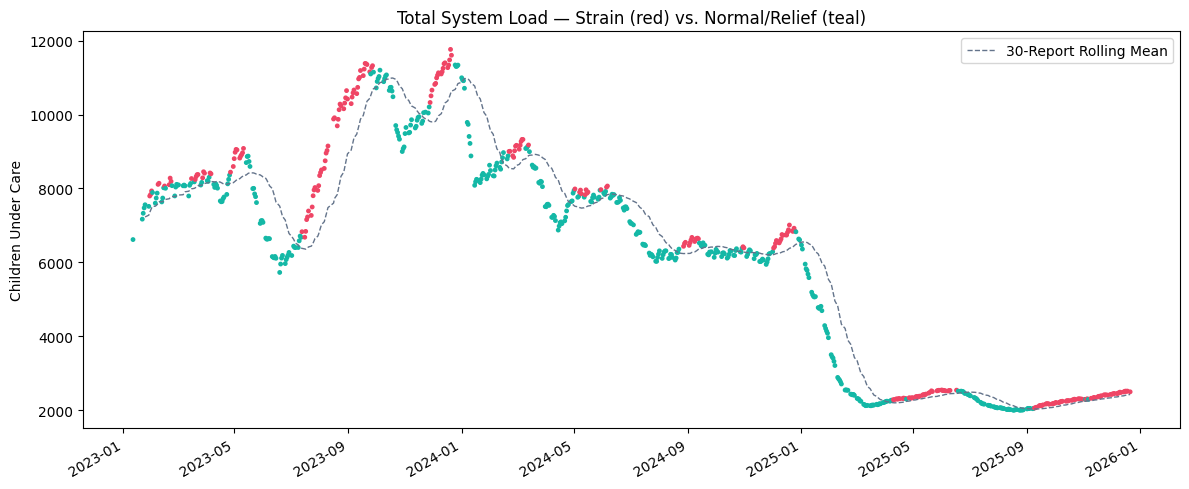

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = df["StrainLabel"].map({"Strain": "#ef4565", "Normal/Relief": "#14b8a6"})
ax.scatter(df["Date"], df["TotalSystemLoad"], c=colors, s=6)
ax.plot(df["Date"], roll_mean_30, color="#64748b", linewidth=1, linestyle="--", label="30-Report Rolling Mean")
ax.set_title("Total System Load — Strain (red) vs. Normal/Relief (teal)")
ax.set_ylabel("Children Under Care")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

---
# B. KPI 1 — Total Children Under Care

In [5]:
latest_day = df.iloc[-1]
total_children_under_care = latest_day["TotalSystemLoad"]

print(f"Latest reporting date       : {latest_day['Date'].date()}")
print(f"Total Children Under Care   : {total_children_under_care:,.0f}")
print(f"  - in CBP custody          : {latest_day['CBP_Custody']:,.0f}")
print(f"  - in HHS care             : {latest_day['HHS_Care']:,.0f}")
print(f"Period average system load  : {df['TotalSystemLoad'].mean():,.0f}")

Latest reporting date       : 2025-12-21
Total Children Under Care   : 2,502
  - in CBP custody          : 18
  - in HHS care             : 2,484
Period average system load  : 6,233


---
# C. KPI 2 — Net Intake Pressure

In [6]:
net_intake_pressure = df["NetDailyIntake"].mean()
print(f"Net Intake Pressure (avg. transfers − discharges per report): {net_intake_pressure:+.2f}")

if net_intake_pressure > 0:
    print("On average, the system is taking in more children than it discharges — inflow-dominant.")
else:
    print("On average, the system is discharging at least as fast as it takes in — outflow-dominant.")

Net Intake Pressure (avg. transfers − discharges per report): -44.74
On average, the system is discharging at least as fast as it takes in — outflow-dominant.


In [7]:
# Net Intake Pressure by year, to see whether the imbalance is worsening or improving
df["Year"] = df["Date"].dt.year
yearly_pressure = df.groupby("Year")["NetDailyIntake"].mean().round(2)
yearly_pressure

Year
2023   -130.96
2024      3.44
2025    -12.36
Name: NetDailyIntake, dtype: float64

---
# D. KPI 3 — Care Load Volatility Index

In [8]:
# Volatility Index: 7-day rolling std, expressed as a % of mean total system load
care_load_volatility_index = (df["RollingStd7"].mean() / df["TotalSystemLoad"].mean()) * 100
print(f"Care Load Volatility Index: {care_load_volatility_index:.2f}% of mean system load")

Care Load Volatility Index: 2.22% of mean system load


In [9]:
yearly_volatility = (
    df.groupby("Year")
    .apply(lambda g: (g["RollingStd7"].mean() / g["TotalSystemLoad"].mean()) * 100)
    .round(2)
)
yearly_volatility.rename("Volatility Index (%)")

Year
2023    2.40
2024    1.97
2025    2.35
Name: Volatility Index (%), dtype: float64

---
# E. KPI 4 — Backlog Accumulation Rate

In [10]:
# Average day-over-day change in the 14-report backlog indicator
backlog_accumulation_rate = df["Backlog14"].diff().mean()
print(f"Backlog Accumulation Rate: {backlog_accumulation_rate:+.3f} per report")

backlog_building_share = (df["BacklogLabel"] == "Backlog Building").mean() * 100
print(f"Share of reporting days with backlog building: {backlog_building_share:.1f}%")

Backlog Accumulation Rate: +0.538 per report
Share of reporting days with backlog building: 35.3%


---
# F. KPI 5 — Discharge Offset Ratio

In [11]:
# What share of everything transferred into HHS care over the period was
# offset by a discharge
total_transferred = df["CBP_Transferred"].sum()
total_discharged = df["HHS_Discharged"].sum()
discharge_offset_ratio = (total_discharged / total_transferred) * 100 if total_transferred else 0

print(f"Total transferred into HHS care over period : {total_transferred:,.0f}")
print(f"Total discharged from HHS care over period  : {total_discharged:,.0f}")
print(f"Discharge Offset Ratio                      : {discharge_offset_ratio:.2f}%")

Total transferred into HHS care over period : 92,641
Total discharged from HHS care over period  : 124,853
Discharge Offset Ratio                      : 134.77%


---
# G. KPI Summary Table

In [12]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Children Under Care (latest)",
        "Net Intake Pressure (avg/report)",
        "Care Load Volatility Index (%)",
        "Backlog Accumulation Rate (avg/report)",
        "Discharge Offset Ratio (%)",
    ],
    "Value": [
        f"{total_children_under_care:,.0f}",
        f"{net_intake_pressure:+.2f}",
        f"{care_load_volatility_index:.2f}%",
        f"{backlog_accumulation_rate:+.3f}",
        f"{discharge_offset_ratio:.2f}%",
    ],
})
kpi_summary

,KPI,Value
0,Total Children Under Care (latest),"2,502"
1,Net Intake Pressure (avg/report),-44.74
2,Care Load Volatility Index (%),2.22%
3,Backlog Accumulation Rate (avg/report),+0.538
4,Discharge Offset Ratio (%),134.77%


---
# H. Pressure & Stress Identification — Strain Windows

In [13]:
df["StrainGroup"] = (df["StrainLabel"] != df["StrainLabel"].shift()).cumsum()
strain_windows = (
    df[df["StrainLabel"] == "Strain"]
    .groupby("StrainGroup")
    .agg(start=("Date", "min"), end=("Date", "max"), reports=("Date", "size"),
         peak_load=("TotalSystemLoad", "max"))
    .reset_index(drop=True)
    .sort_values("reports", ascending=False)
)
strain_windows.head(10)

,start,end,reports,peak_load
9,2023-07-13,2023-09-24,48,11382.0
24,2025-09-09,2025-11-02,38,2313.0
23,2025-04-27,2025-06-17,31,2552.0
26,2025-11-09,2025-12-21,29,2522.0
11,2023-11-28,2023-12-21,18,11762.0
21,2024-12-02,2024-12-25,18,7012.0
12,2024-02-21,2024-03-07,12,9327.0
19,2024-08-27,2024-09-12,12,6678.0
22,2025-04-10,2025-04-23,11,2333.0
8,2023-04-27,2023-05-11,11,9084.0


### Observation

These are the longest sustained strain windows over the full reporting
period, ranked by duration. Each one pairs a start/end date with the peak
system load reached during that window — the set of episodes a staffing and
capacity post-mortem would review first.

---
# Saving the Final KPI Dataset

In [14]:
df.to_csv("../data/Processed/UAC_cleaned.csv", index=False)
kpi_summary.to_csv("../data/Processed/UAC_kpi_summary.csv", index=False)
print("Saved final dataset to ../data/Processed/UAC_cleaned.csv")
print("Saved KPI summary to ../data/Processed/UAC_kpi_summary.csv")

Saved final dataset to ../data/Processed/UAC_cleaned.csv
Saved KPI summary to ../data/Processed/UAC_kpi_summary.csv


---
# Conclusion

All five project KPIs were computed successfully, and capacity strain
windows were identified for operational review:

### Key Findings

- **Total Children Under Care** stood at the latest reporting day's total
  system load, with a full-period average also reported for context.
- **Net Intake Pressure** shows whether the pipeline is, on average,
  inflow-dominant or outflow-dominant, both overall and broken out by year.
- **Care Load Volatility Index** quantifies system stability as 7-day
  rolling volatility relative to mean load — a signal that spikes ahead of
  sustained strain windows (see Notebook 03).
- **Backlog Accumulation Rate** tracks whether the 14-report backlog
  indicator is, on average, growing or shrinking.
- **Discharge Offset Ratio** measures how much of what moves into HHS care
  gets relieved back out via discharge — the single clearest measure of the
  system's ability to keep pace with intake.
- The longest sustained strain windows were isolated for direct operational
  follow-up.

These KPIs, along with the underlying enriched dataset, feed directly into
the Streamlit dashboard's Overview, Trends & Volatility, and Capacity Stress
Explorer pages.
